# Kunci Jawaban - Linear Regression

- **Dataset:** [Abalone](https://archive.ics.uci.edu/dataset/1/abalone)
- **Target:** `Rings`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [1]:
%pip install -q ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti count plot, bar plot, scatter plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti count plot, regression plot, dan boxplot.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [3]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [4]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [5]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Abalone menggunakan ID dataset dari UCI.

In [6]:
abalone = fetch_ucirepo(id=1)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [7]:
X_raw = abalone.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [8]:
y_raw = abalone.data.targets.copy()

### Tentukan kolom target

Tentukan kolom `Rings` sebagai target prediksi.

In [9]:
TARGET_COL = "Rings"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df`.

In [10]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [11]:
df.shape

(4177, 9)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 4177 baris dan 9 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [12]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.514,0.225,0.101,0.150,15
1,M,0.350,0.265,0.090,0.226,0.100,0.049,0.070,7
2,F,0.530,0.420,0.135,0.677,0.257,0.141,0.210,9
3,M,0.440,0.365,0.125,0.516,0.215,0.114,0.155,10
4,I,0.330,0.255,0.080,0.205,0.089,0.040,0.055,7


> Berdasarkan lima baris pertama, kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `Rings`.

> Kolom mana yang berisi kategori?

Jawaban: Kolom `Sex` berisi kategori.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `object`, `float64`, dan `int64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 4177 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan kategori.

In [16]:
df.describe(include="all")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177,4177.000,4177.000,4177.000,4177.000,4177.000,4177.000,4177.000,4177.000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.524,0.408,0.140,0.829,0.359,0.181,0.239,9.934
std,NaN,0.120,0.099,0.042,0.490,0.222,0.110,0.139,3.224
min,NaN,0.075,0.055,0.000,0.002,0.001,0.001,0.002,1.000
25%,NaN,0.450,0.350,0.115,0.442,0.186,0.093,0.130,8.000
50%,NaN,0.545,0.425,0.140,0.799,0.336,0.171,0.234,9.000
75%,NaN,0.615,0.480,0.165,1.153,0.502,0.253,0.329,11.000


> Berdasarkan statistik deskriptif, berapa rata-rata target `Rings`?

Jawaban: Rata-rata target `Rings` sekitar 9.934.

> Berdasarkan statistik deskriptif, kategori `Sex` apa yang paling sering muncul?

Jawaban: Kategori `M` paling sering muncul.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [17]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [18]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [19]:
df_clean.shape

(4177, 9)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 4177 baris dan 9 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [20]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Rings`.

In [21]:
df_clean[TARGET_COL].describe()

count   4177.000
mean       9.934
std        3.224
min        1.000
25%        8.000
50%        9.000
75%       11.000
max       29.000
Name: Rings, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 9.934, minimum 1.000, dan maksimum 29.000.

### Buat count plot target

Gunakan count plot karena target `Rings` berupa bilangan hitungan.

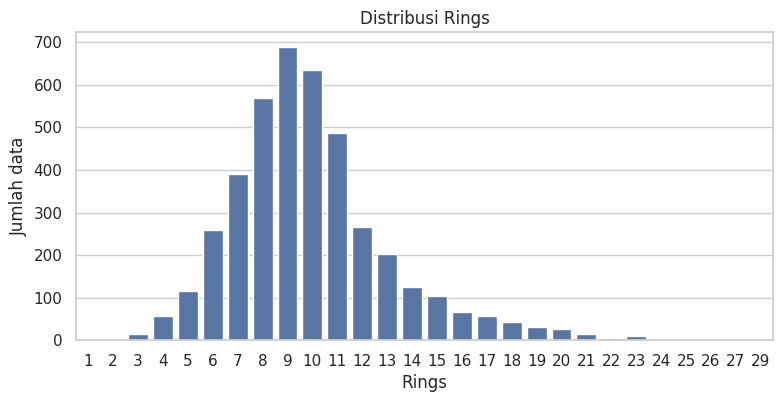

In [22]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df_clean, x=TARGET_COL)
plt.title("Distribusi Rings")
plt.xlabel("Rings")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan count plot, nilai `Rings` mana yang paling banyak muncul?

Jawaban: Nilai `Rings` yang paling banyak muncul adalah 9.

> Mengapa count plot lebih tepat daripada histogram biasa untuk target ini?

Jawaban: Count plot lebih tepat karena `Rings` adalah bilangan hitungan diskrit.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `Rings`.

In [23]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

Shell_weight     0.628
Diameter         0.575
Height           0.557
Length           0.557
Whole_weight     0.540
Viscera_weight   0.504
Shucked_weight   0.421
Name: Rings, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `Shell_weight` memiliki korelasi positif paling tinggi terhadap target.

> Apakah semua fitur numerik memiliki korelasi positif terhadap target?

Jawaban: Ya. Semua fitur numerik memiliki korelasi positif terhadap `Rings`.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

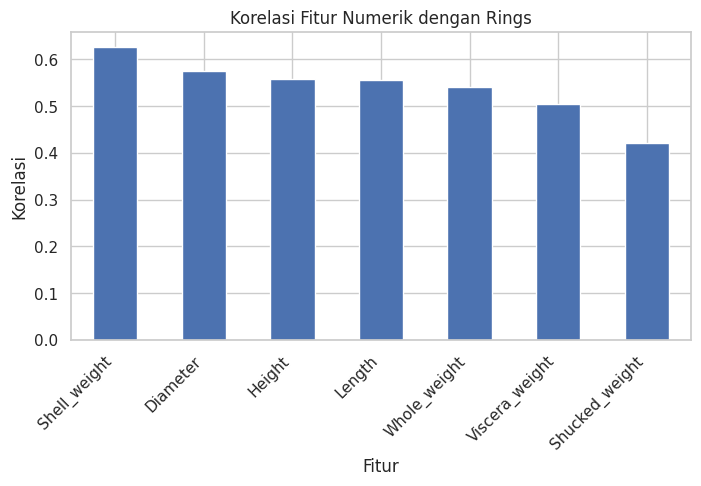

In [24]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Numerik dengan Rings")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur numerik mana yang terlihat paling kuat hubungannya dengan target?

Jawaban: `Shell_weight` terlihat paling kuat hubungannya dengan target.

### Buat boxplot Rings berdasarkan Sex

Gunakan boxplot untuk membandingkan persebaran `Rings` pada setiap kategori `Sex`.

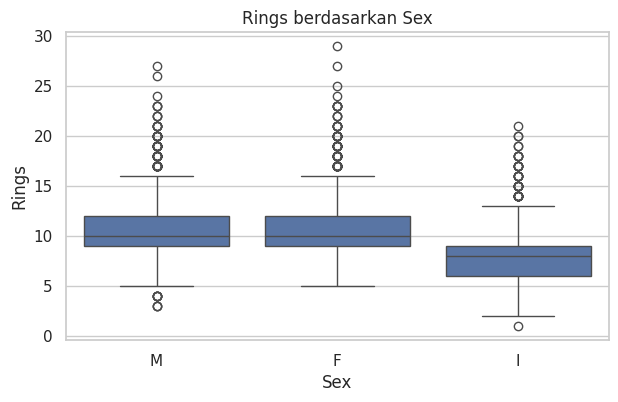

In [25]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="Sex", y=TARGET_COL)
plt.title("Rings berdasarkan Sex")
plt.xlabel("Sex")
plt.ylabel("Rings")
plt.show()

> Berdasarkan boxplot, kategori `Sex` mana yang cenderung memiliki Rings lebih tinggi?

Jawaban: Kategori `F` dan `M` cenderung memiliki Rings lebih tinggi.

> Kategori `Sex` mana yang cenderung memiliki Rings lebih rendah?

Jawaban: Kategori `I` cenderung memiliki Rings lebih rendah.

### Buat scatter plot Shell_weight dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan `Shell_weight` dengan target.

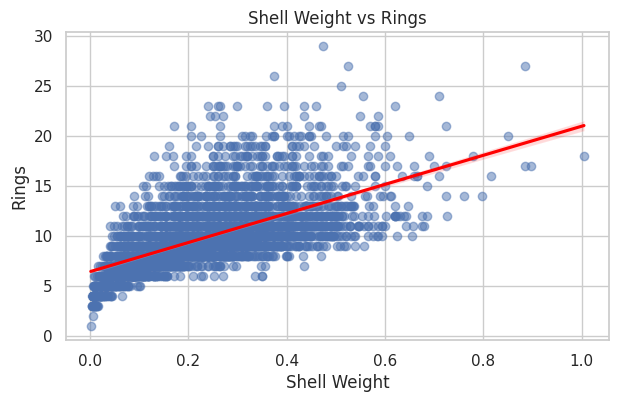

In [26]:
plt.figure(figsize=(7, 4))
sns.regplot(data=df_clean, x="Shell_weight", y=TARGET_COL, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title("Shell Weight vs Rings")
plt.xlabel("Shell Weight")
plt.ylabel("Rings")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Shell_weight` dengan target?

Jawaban: Polanya cenderung positif; semakin tinggi `Shell_weight`, nilai `Rings` cenderung lebih tinggi.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan positif.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan semua kolom selain target sebagai fitur awal.

In [27]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [28]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi kolom numerik menggunakan `pd.get_dummies()`.

In [29]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Tampilkan ukuran `X` setelah kolom kategori diubah menjadi numerik.

In [30]:
X.shape

(4177, 9)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki 4177 baris dan 9 fitur setelah encoding.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [31]:
y.shape

(4177,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 4177 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [34]:
X_train.shape

(3341, 9)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [35]:
X_test.shape

(836, 9)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 3341 baris dan data test memiliki 836 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [41]:
model.intercept_

np.float64(9.944627357078721)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 9.945.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
3,Whole_weight,4.390
6,Shell_weight,1.230
1,Diameter,1.098
2,Height,0.444
8,Sex_M,0.050
0,Length,-0.024
7,Sex_I,-0.336
5,Viscera_weight,-1.046
4,Shucked_weight,-4.517


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `Whole_weight` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `Shucked_weight` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,9,11.761
1,8,10.242
2,16,14.001
3,9,11.995
4,14,11.161


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris ketiga terlihat paling dekat karena actual 16.000 dan predicted sekitar 14.001.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 9.000 dan predicted sekitar 11.995.

### Hitung MAE train

Hitung MAE pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

1.576427757822827

### Hitung MAE test

Hitung MAE pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

1.5931067816608366

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 1.593.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(2.187202344131259)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(2.2116130871218367)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 2.212.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.5348243545188456

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5481628137889262

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.548.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [52]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,1.576,2.187,0.535
1,Test,1.593,2.212,0.548


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 1.06% lebih tinggi daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 1.12% lebih tinggi daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 2.49% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

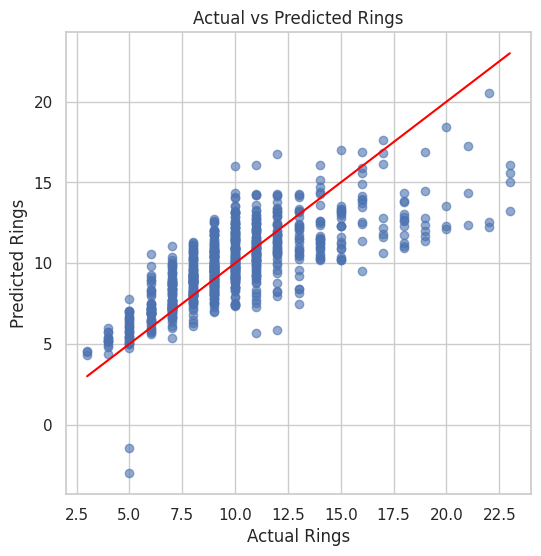

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Rings")
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.show()

## 11 - Kesimpulan

Dataset Abalone digunakan untuk memprediksi `Rings` berdasarkan ukuran fisik dan berat abalone. Dataset memiliki 4177 baris dan 9 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Rings` berupa bilangan hitungan diskrit. Nilai `Rings` yang paling banyak muncul adalah 9, dan fitur numerik dengan korelasi positif paling tinggi terhadap target adalah `Shell_weight`. Kolom `Sex` diubah menjadi numerik menggunakan `pd.get_dummies()`.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 1.593, RMSE test sekitar 2.212, dan R2 test sekitar 0.548.